In [ ]:
import pandas as pd
import numpy as py
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df=pd.read_csv("credit_card.csv")

In [ ]:
df

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0


In [ ]:
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [ ]:
df.tail()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0
9999,10000,44.06,2,Clothing,0,0,38,0,66,0


In [ ]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [ ]:
(df.duplicated())

,0
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [ ]:
df.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [ ]:
df.notnull()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,True,True,True,True,True,True,True,True,True,True
1,True,True,True,True,True,True,True,True,True,True
2,True,True,True,True,True,True,True,True,True,True
3,True,True,True,True,True,True,True,True,True,True
4,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...
9995,True,True,True,True,True,True,True,True,True,True
9996,True,True,True,True,True,True,True,True,True,True
9997,True,True,True,True,True,True,True,True,True,True
9998,True,True,True,True,True,True,True,True,True,True


In [ ]:
print(df.columns)

Index(['transaction_id', 'amount', 'transaction_hour', 'merchant_category',
       'foreign_transaction', 'location_mismatch', 'device_trust_score',
       'velocity_last_24h', 'cardholder_age', 'is_fraud'],
      dtype='object')


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['merchant_category'] = le.fit_transform(df['merchant_category']).astype(float)

In [ ]:
df = pd.get_dummies(df, columns=['merchant_category'], dtype=float)

In [ ]:
df

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,merchant_category_0.0,merchant_category_1.0,merchant_category_2.0,merchant_category_3.0,merchant_category_4.0
0,1,84.47,22,0,0,66,3,40,0,0.0,1.0,0.0,0.0,0.0
1,2,541.82,3,1,0,87,1,64,0,0.0,0.0,0.0,0.0,1.0
2,3,237.01,17,0,0,49,1,61,0,0.0,0.0,0.0,1.0,0.0
3,4,164.33,4,0,1,72,3,34,0,0.0,0.0,0.0,1.0,0.0
4,5,30.53,15,0,0,79,0,44,0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,0,0,99,4,37,0,0.0,0.0,1.0,0.0,0.0
9996,9997,410.04,5,0,0,70,3,25,0,1.0,0.0,0.0,0.0,0.0
9997,9998,527.75,21,0,0,44,2,45,0,0.0,1.0,0.0,0.0,0.0
9998,9999,91.20,2,0,0,38,0,37,0,0.0,1.0,0.0,0.0,0.0


/tmp/ipykernel_856/3434566682.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=df, palette='rainbow')


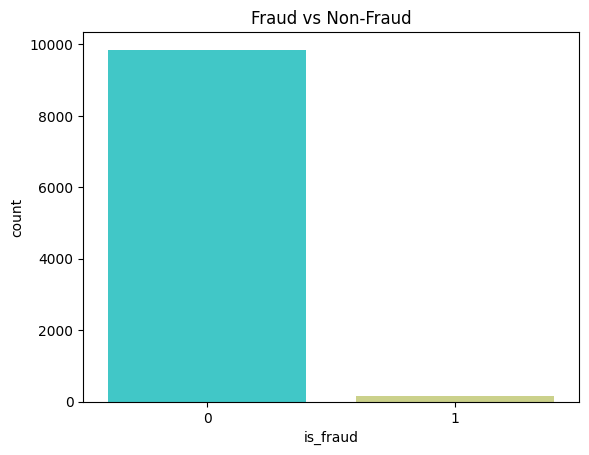

In [ ]:
sns.countplot(x='is_fraud', data=df, palette='rainbow')
plt.title("Fraud vs Non-Fraud")
plt.show()

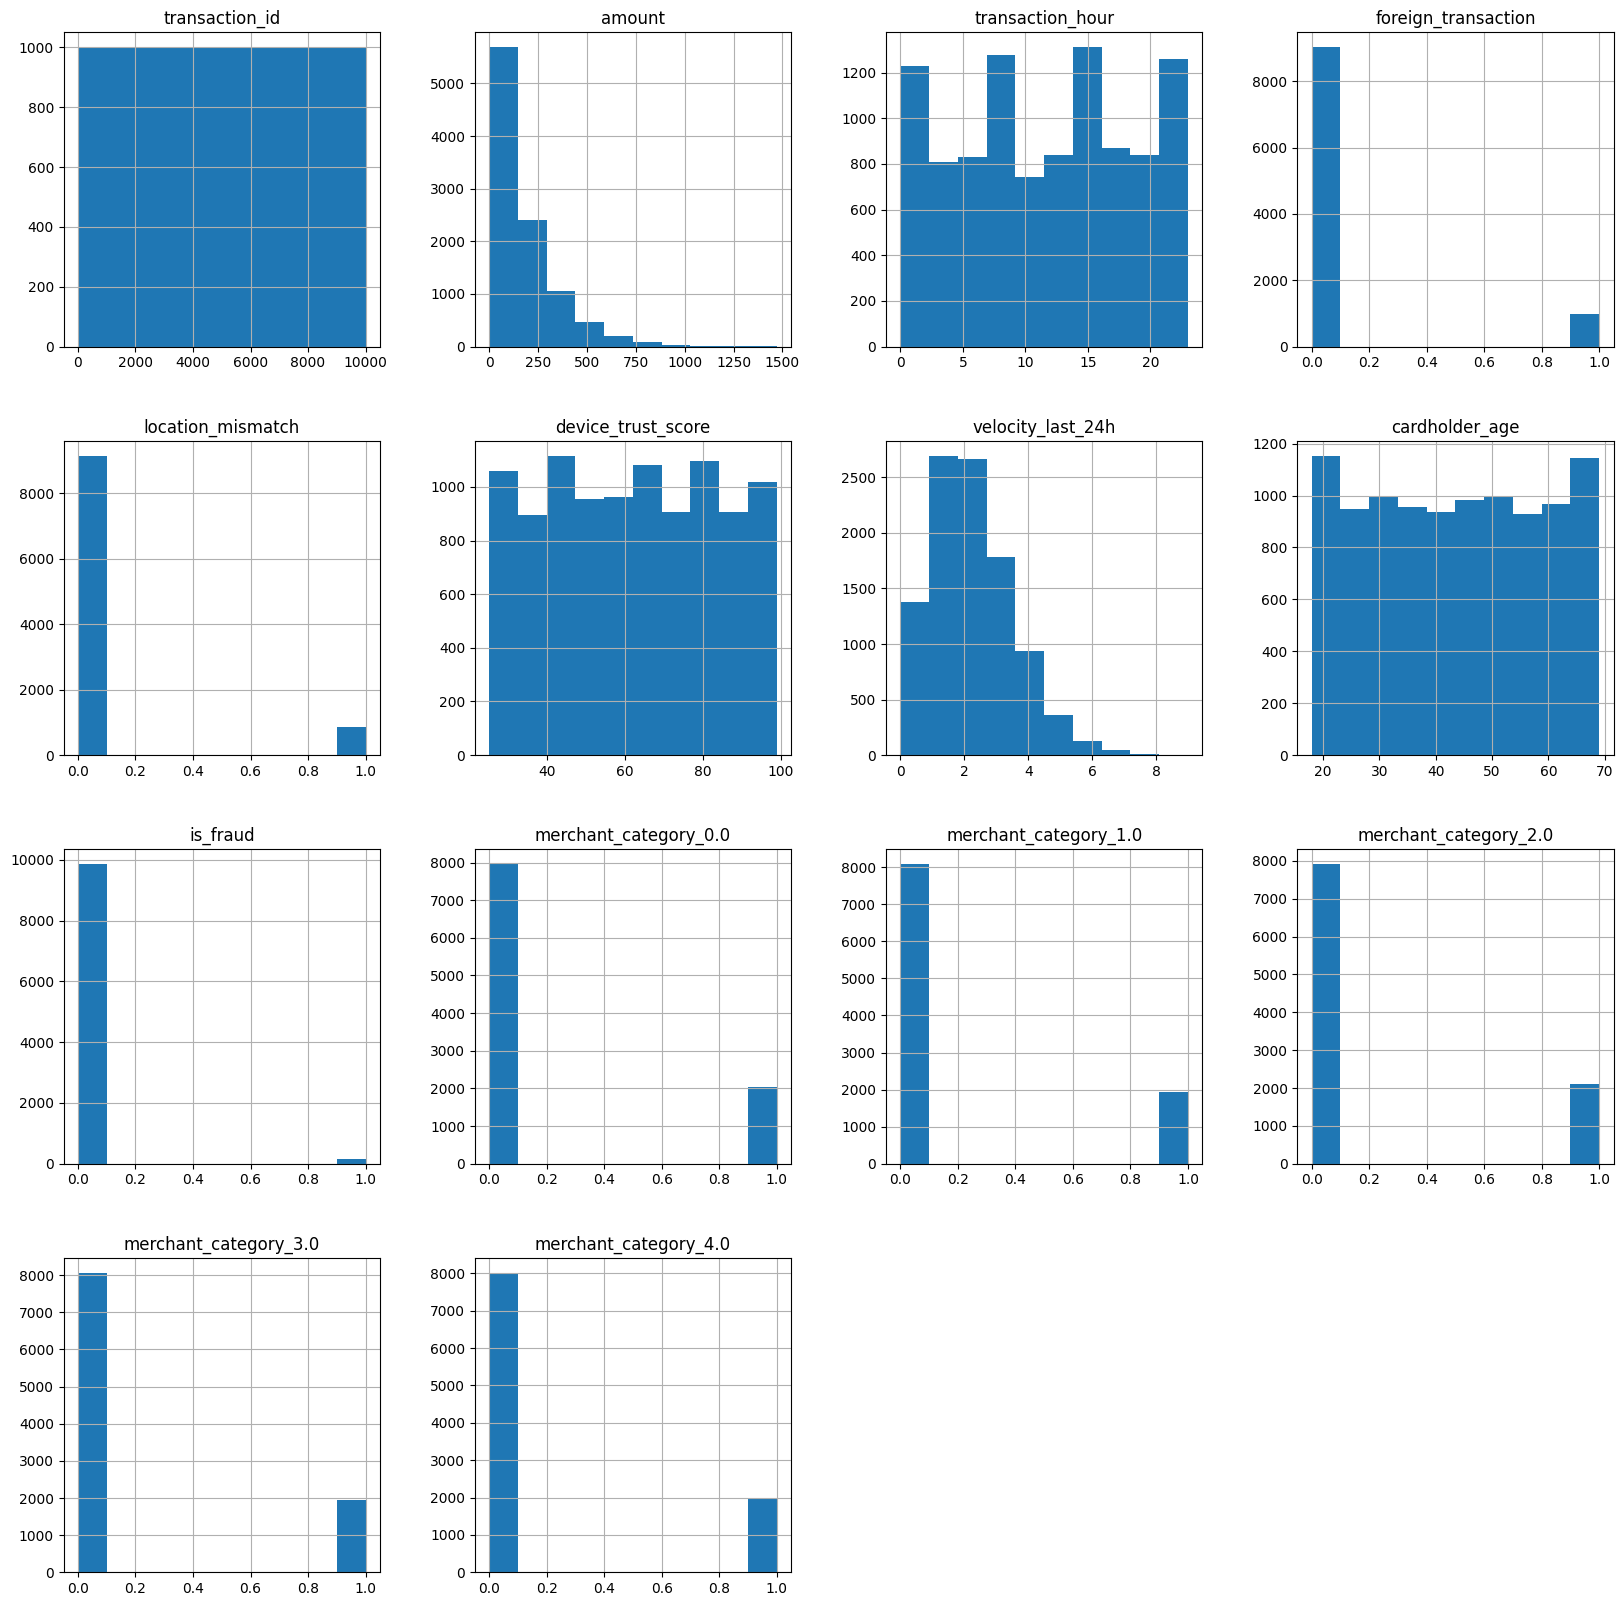

In [ ]:
df.hist(figsize=(20,20))
plt.show()

/tmp/ipykernel_856/4268640535.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], palette='rainbow')


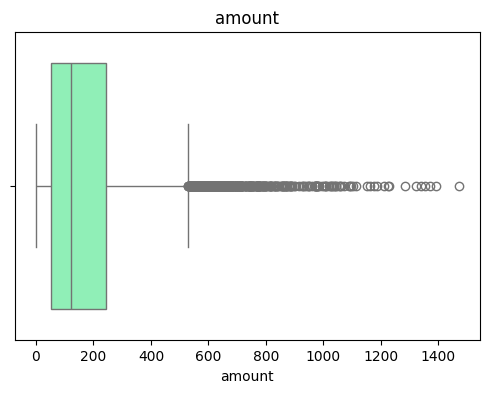

/tmp/ipykernel_856/4268640535.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], palette='rainbow')


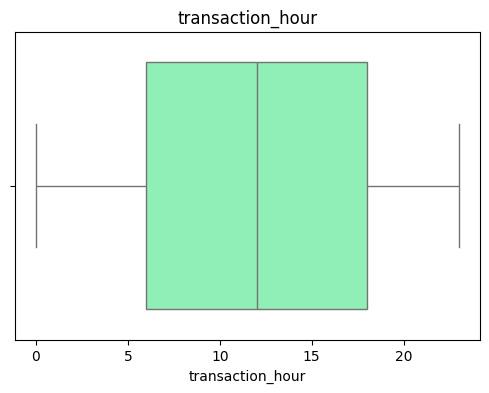

/tmp/ipykernel_856/4268640535.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], palette='rainbow')


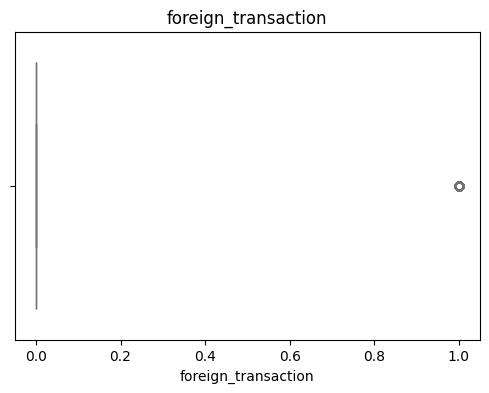

/tmp/ipykernel_856/4268640535.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], palette='rainbow')


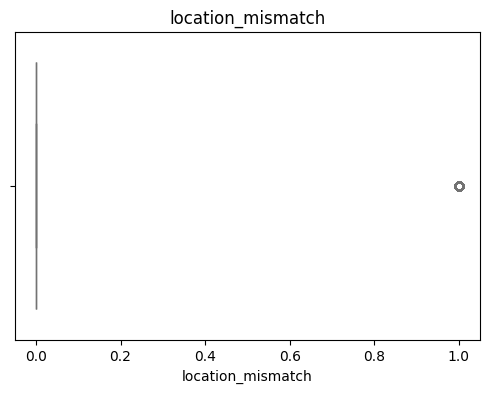

/tmp/ipykernel_856/4268640535.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], palette='rainbow')


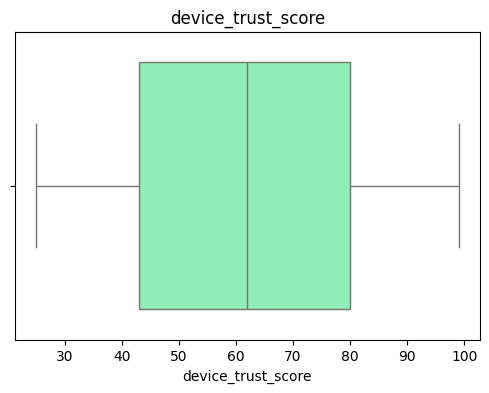

/tmp/ipykernel_856/4268640535.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], palette='rainbow')


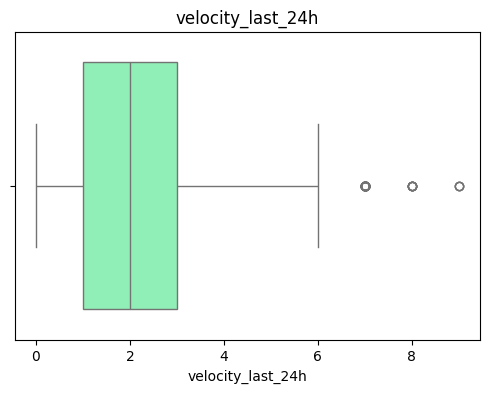

/tmp/ipykernel_856/4268640535.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], palette='rainbow')


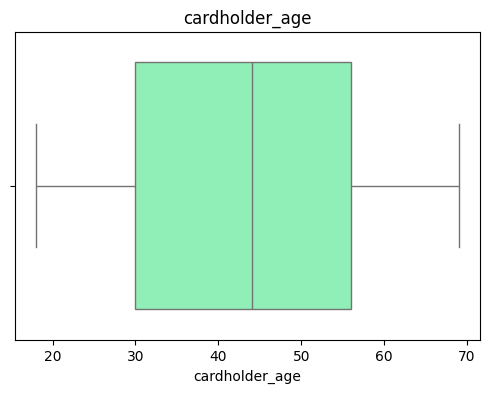

In [ ]:
numeric_columns = ['amount', 'transaction_hour', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], palette='rainbow')
    plt.title(col)
    plt.show()

In [ ]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

In [ ]:
X

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_0.0,merchant_category_1.0,merchant_category_2.0,merchant_category_3.0,merchant_category_4.0
0,1,84.47,22,0,0,66,3,40,0.0,1.0,0.0,0.0,0.0
1,2,541.82,3,1,0,87,1,64,0.0,0.0,0.0,0.0,1.0
2,3,237.01,17,0,0,49,1,61,0.0,0.0,0.0,1.0,0.0
3,4,164.33,4,0,1,72,3,34,0.0,0.0,0.0,1.0,0.0
4,5,30.53,15,0,0,79,0,44,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,0,0,99,4,37,0.0,0.0,1.0,0.0,0.0
9996,9997,410.04,5,0,0,70,3,25,1.0,0.0,0.0,0.0,0.0
9997,9998,527.75,21,0,0,44,2,45,0.0,1.0,0.0,0.0,0.0
9998,9999,91.20,2,0,0,38,0,37,0.0,1.0,0.0,0.0,0.0


In [ ]:
X

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_0.0,merchant_category_1.0,merchant_category_2.0,merchant_category_3.0,merchant_category_4.0
0,1,84.47,22,0,0,66,3,40,0.0,1.0,0.0,0.0,0.0
1,2,541.82,3,1,0,87,1,64,0.0,0.0,0.0,0.0,1.0
2,3,237.01,17,0,0,49,1,61,0.0,0.0,0.0,1.0,0.0
3,4,164.33,4,0,1,72,3,34,0.0,0.0,0.0,1.0,0.0
4,5,30.53,15,0,0,79,0,44,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,0,0,99,4,37,0.0,0.0,1.0,0.0,0.0
9996,9997,410.04,5,0,0,70,3,25,1.0,0.0,0.0,0.0,0.0
9997,9998,527.75,21,0,0,44,2,45,0.0,1.0,0.0,0.0,0.0
9998,9999,91.20,2,0,0,38,0,37,0.0,1.0,0.0,0.0,0.0


In [ ]:
X

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_0.0,merchant_category_1.0,merchant_category_2.0,merchant_category_3.0,merchant_category_4.0
0,1,84.47,22,0,0,66,3,40,0.0,1.0,0.0,0.0,0.0
1,2,541.82,3,1,0,87,1,64,0.0,0.0,0.0,0.0,1.0
2,3,237.01,17,0,0,49,1,61,0.0,0.0,0.0,1.0,0.0
3,4,164.33,4,0,1,72,3,34,0.0,0.0,0.0,1.0,0.0
4,5,30.53,15,0,0,79,0,44,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,0,0,99,4,37,0.0,0.0,1.0,0.0,0.0
9996,9997,410.04,5,0,0,70,3,25,1.0,0.0,0.0,0.0,0.0
9997,9998,527.75,21,0,0,44,2,45,0.0,1.0,0.0,0.0,0.0
9998,9999,91.20,2,0,0,38,0,37,0.0,1.0,0.0,0.0,0.0


In [ ]:
y

,is_fraud
0,0
1,0
2,0
3,0
4,0
...,...
9995,0
9996,0
9997,0
9998,0


In [ ]:
#Feature scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
df

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,merchant_category_0.0,merchant_category_1.0,merchant_category_2.0,merchant_category_3.0,merchant_category_4.0
0,1,84.47,22,0,0,66,3,40,0,0.0,1.0,0.0,0.0,0.0
1,2,541.82,3,1,0,87,1,64,0,0.0,0.0,0.0,0.0,1.0
2,3,237.01,17,0,0,49,1,61,0,0.0,0.0,0.0,1.0,0.0
3,4,164.33,4,0,1,72,3,34,0,0.0,0.0,0.0,1.0,0.0
4,5,30.53,15,0,0,79,0,44,0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,0,0,99,4,37,0,0.0,0.0,1.0,0.0,0.0
9996,9997,410.04,5,0,0,70,3,25,0,1.0,0.0,0.0,0.0,0.0
9997,9998,527.75,21,0,0,44,2,45,0,0.0,1.0,0.0,0.0,0.0
9998,9999,91.20,2,0,0,38,0,37,0,0.0,1.0,0.0,0.0,0.0


In [ ]:
classifier=KNeighborsClassifier(n_neighbors=5)
classifier.fit(X_train,y_train)

KNeighborsClassifier()

In [ ]:
y_pred=classifier.predict(X_test)

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1969
           1       1.00      0.13      0.23        31

    accuracy                           0.99      2000
   macro avg       0.99      0.56      0.61      2000
weighted avg       0.99      0.99      0.98      2000



In [ ]:
accuracy_score(y_test,y_pred)

0.9865

In [ ]:
confusion_matrix(y_test,y_pred)

array([[1969,    0],
       [  27,    4]])

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1969
           1       1.00      0.13      0.23        31

    accuracy                           0.99      2000
   macro avg       0.99      0.56      0.61      2000
weighted avg       0.99      0.99      0.98      2000



In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
model_NB = GaussianNB()

In [ ]:
model_NB.fit(X_train,y_train)

GaussianNB()

In [ ]:
y_pred_NB=model_NB.predict(X_test)

In [ ]:
y_pred_NB

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:

accuracy_score(y_test,y_pred_NB)

0.9795

In [ ]:
confusion_matrix(y_test,y_pred_NB)

array([[1937,   32],
       [   9,   22]])

In [ ]:
print(classification_report(y_test,y_pred_NB))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1969
           1       0.41      0.71      0.52        31

    accuracy                           0.98      2000
   macro avg       0.70      0.85      0.75      2000
weighted avg       0.99      0.98      0.98      2000



In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model_DT=DecisionTreeClassifier(random_state=42)

In [ ]:
model_DT.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_DT=model_DT.predict(X_test)

In [ ]:
y_pred_DT

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
accuracy_score(y_test,y_pred_DT)

0.9985

In [ ]:
confusion_matrix(y_test,y_pred_DT)

array([[1968,    1],
       [   2,   29]])

In [ ]:
print(classification_report(y_test,y_pred_DT))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1969
           1       0.97      0.94      0.95        31

    accuracy                           1.00      2000
   macro avg       0.98      0.97      0.98      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
from sklearn.svm import SVC

In [ ]:
model_svm=SVC(kernel="linear")

In [ ]:
model_svm.fit(X_train,y_train)

SVC(kernel='linear')

In [ ]:
y_pred_svc = model_svm.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred_svc)

0.9905

In [ ]:
confusion_matrix(y_test,y_pred_svc)

array([[1967,    2],
       [  17,   14]])

In [ ]:
print(classification_report(y_test,y_pred_svc))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1969
           1       0.88      0.45      0.60        31

    accuracy                           0.99      2000
   macro avg       0.93      0.73      0.80      2000
weighted avg       0.99      0.99      0.99      2000



## Predict Fraud with User Input

Now, let's create an interactive way to predict if a transaction is fraudulent based on user-provided inputs for the transaction features.

In [ ]:
import pandas as pd
import numpy as py
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Load the DataFrame to ensure 'df' is defined
df = pd.read_csv("credit_card.csv")

# Define the feature names in the correct order as used for training
# Exclude 'merchant_category' as it was dropped from the training features
feature_names = [
    'amount',
    'transaction_hour',
    'foreign_transaction',
    'location_mismatch',
    'device_trust_score',
    'velocity_last_24h',
    'cardholder_age'
]

# Prepare the data for training
# Drop 'is_fraud', 'transaction_id', and 'merchant_category'
X = df.drop(['is_fraud', 'transaction_id', 'merchant_category'], axis=1)
y = df['is_fraud']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

# Initialize and train the Decision Tree model
model_DT = DecisionTreeClassifier(random_state=42)
model_DT.fit(X_train, y_train)

def predict_fraud_with_input(model, scaler, feature_names):
    user_input = []
    print("\nPlease enter the following transaction details:")
    for feature in feature_names:
        while True:
            try:
                value = float(input(f"Enter value for {feature}: "))
                user_input.append(value)
                break
            except ValueError:
                print("Invalid input. Please enter a numerical value.")

    # Convert the user input to a NumPy array and reshape for scaling
    input_array = py.array(user_input).reshape(1, -1)

    # Scale the user input using the same scaler fitted on the training data
    scaled_input = scaler.transform(input_array)

    # Make a prediction using the trained model
    prediction = model.predict(scaled_input)

    if prediction[0] == 1:
        print("\nPrediction: This transaction is likely fraudulent.")
    else:
        print("\nPrediction: This transaction is likely not fraudulent.")

# Call the function with the trained Decision Tree model and the scaler
predict_fraud_with_input(model_DT, scaler, feature_names)



Please enter the following transaction details:
Enter value for amount: 90
Enter value for transaction_hour: 80
Enter value for foreign_transaction: 70
Enter value for location_mismatch: 0
Enter value for device_trust_score: 50
Enter value for velocity_last_24h: 30
Enter value for cardholder_age: 40

Prediction: This transaction is likely not fraudulent.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import joblib

# Save the trained Decision Tree model
joblib.dump(model_DT, "credit_card.pkl")

# Save the fitted scaler
joblib.dump(scaler, "scaler.pkl")

# Save the feature names
joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']